UNet_Activation_Map_Visualization.ipynb

In [1]:
pip install torch torchvision matplotlib numpy pillow segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import segmentation_models_pytorch as smp


In [3]:
# Load pretrained U-Net (encoder pretrained on ImageNet)
model = smp.Unet(
    encoder_name="resnet34",        # encoder backbone
    encoder_weights="imagenet",     # use pretrained weights
    in_channels=3,                  # RGB
    classes=1,                      # dummy single output class
)
model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [5]:
from io import BytesIO
import requests

# Download image from the internet
url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131?w=512"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

# Define transforms
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])

x = transform(img).unsqueeze(0)  # shape: (1, 3, 256, 256)


In [7]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks
model.encoder.layer1.register_forward_hook(get_activation('early'))
model.encoder.layer3.register_forward_hook(get_activation('mid'))
model.decoder.blocks[-1].register_forward_hook(get_activation('late'))



In [8]:
with torch.no_grad():
    _ = model(x)


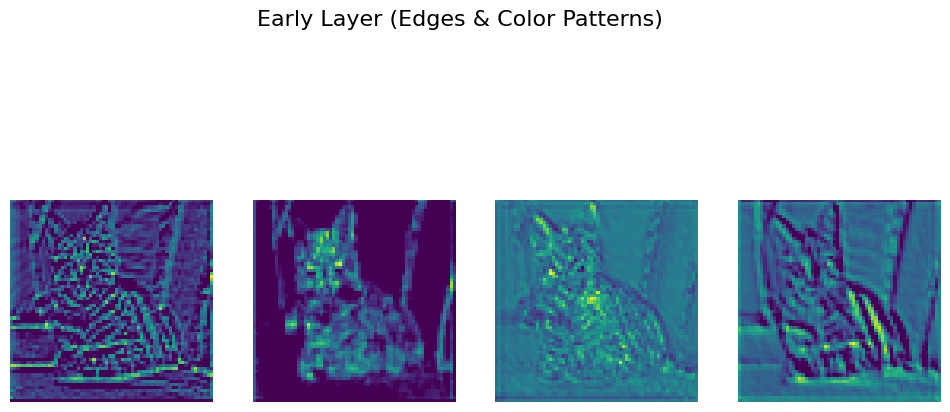

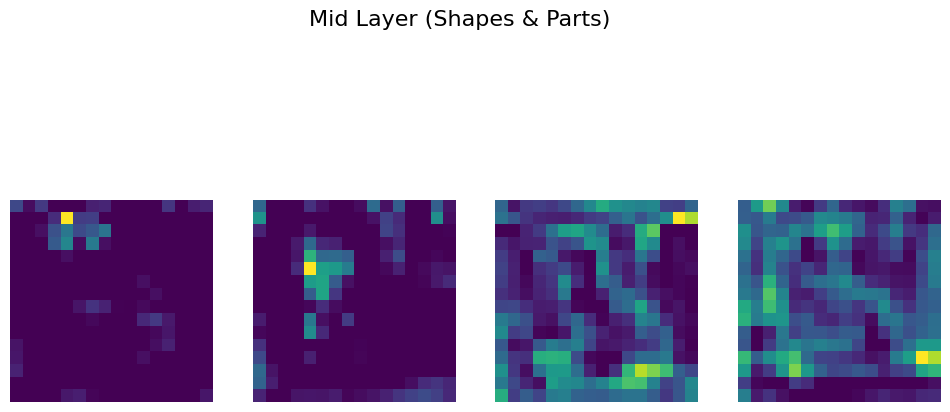

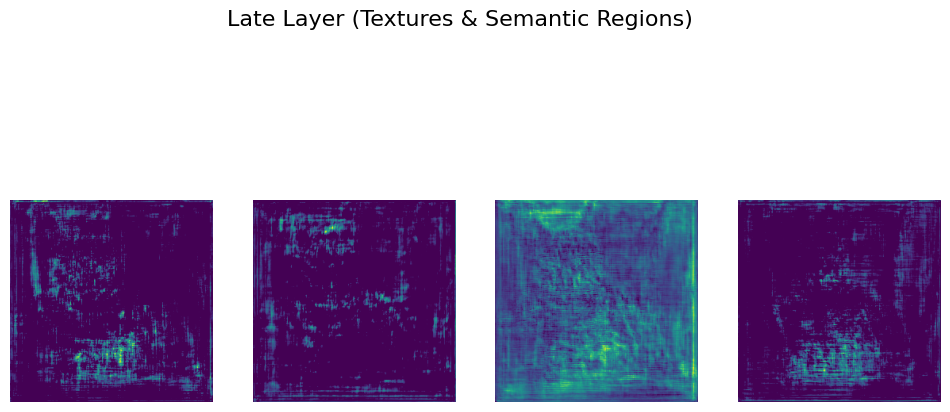

In [9]:
def show_feature_maps(act, title):
    act = act.squeeze(0)  # remove batch dimension
    num_channels = act.shape[0]
    fig, axs = plt.subplots(1, 4, figsize=(12, 6))
    for i in range(4):
        axs[i].imshow(act[i].cpu(), cmap='viridis')
        axs[i].axis('off')
    fig.suptitle(title, fontsize=16)
    plt.show()

# Display activations
show_feature_maps(activations['early'], "Early Layer (Edges & Color Patterns)")
show_feature_maps(activations['mid'], "Mid Layer (Shapes & Parts)")
show_feature_maps(activations['late'], "Late Layer (Textures & Semantic Regions)")
